# Demo of Annealed SVGD DISC tomography based on checkboard model 

## Description
This notebook implements annealed SVGD DISC based on checkboard model for uncertainty estimation.  
It is designed for generating synthetic data, performing ray path matrix reconstruction, and updating velocity models through gradient-based optimization.


## Date
2026-07

In [ ]:
#####Step1 import necessary package

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import lsqr
import sys
from pyekfmm import eikonal,ray2d2  #extract traveltime and ray tracing (new) functions from pyekfmm
from pyseistr.solvers import solver,conjgrad
from pyseistr.solvers import cgstep
from pyseistr.operators import adjnull,matrix_lop
from pyseistr.divne import trianglen_lop
from scipy.ndimage import gaussian_filter
import os
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
#####Step2 create real checkboard model

nx, ny = 50, 50  ###model size 
dx = dy =1       ###spacing rinterval

shape = (50, 50)
tile = (5, 5)  # (tile_height, tile_width); change as needed
v_low = 4000     ###low velocity
v_high = 6000    ###high velocity
iy, ix = np.indices(shape)
checker = ((iy // tile[0]) + (ix // tile[1])) % 2
v_true = np.where(checker == 0, v_low, v_high).astype(np.float32)

#########geometry setting
n_sources = 50 ####number of sources
sources = [(10, (i*(ny-1)*dx/(n_sources-1))) for i in range(n_sources)] #### source locations (x,y)
n_receivers = 50  ####number of recevivers
receivers = [((nx-10)*dx, (i*(ny-1)*dy/(n_receivers-1))) for i in range(n_receivers)] ### receiver locations (x,y)

In [12]:
#####Step3 build ray path matrix based on eikonal wave equation

sources_x=[ii[0] for ii in sources] ########x coordinates of sources
sources_y=[ii[1] for ii in sources] ########y coordinates of sources

receivers_x=[ii[0] for ii in receivers] ########x coordinates of receivers
receivers_y=[ii[1] for ii in receivers] ########y coordinates of receivers


from functions import *   ####import necessary functions for traveltime and ray path calculation

###compute traveltime for each ray based on eikonal equation
traveltimes,ray_paths=compute_travel_times(v_true, sources, receivers, dx, dy, nx, ny, 1)  

###build ray path matrix 
A=build_ray_matrix(ray_paths, dx, dy, nx, ny, 0)


obst=(np.squeeze(traveltimes))  ####observed traveltime from Eikonal equation

nd=len(obst) #####length of traveltime vector




Text(0.5, 1.0, 'Observed traveltime (DISC)')

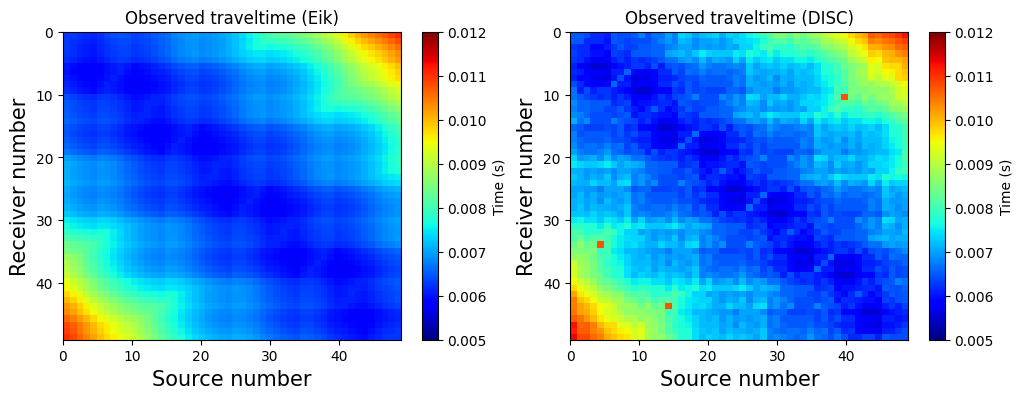

In [4]:
########Step 4 observed travel time comparison

time_eik=np.squeeze(traveltimes).reshape(n_sources,n_receivers)#traveltime estimated usig eikonal equation

time_cal=A.dot(1./v_true.reshape(nx*ny,1,order='C')).reshape(n_sources,n_receivers) #### traveltime calculated using ray path matrix and true velocity model

v_low = 4000
v_hig = 6000

tlow=0.005
thig=0.012

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(time_eik,cmap='jet',vmin=tlow,vmax=thig,extent=[0,(nx-1),(ny-1),0],aspect='auto')
plt.ylabel('Receiver number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Source number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.colorbar(label='Time (s)')
plt.title('Observed traveltime (Eik)')
plt.subplot(1,2,2)
plt.imshow(time_cal,cmap='jet',vmin=tlow,vmax=thig,extent=[0,(nx-1),(ny-1),0],aspect='auto')
plt.ylabel('Receiver number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Source number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.colorbar(label='Time (s)')
plt.title('Observed traveltime (DISC)')


-106.998291015625 114.37738800048828
(10, 2500)


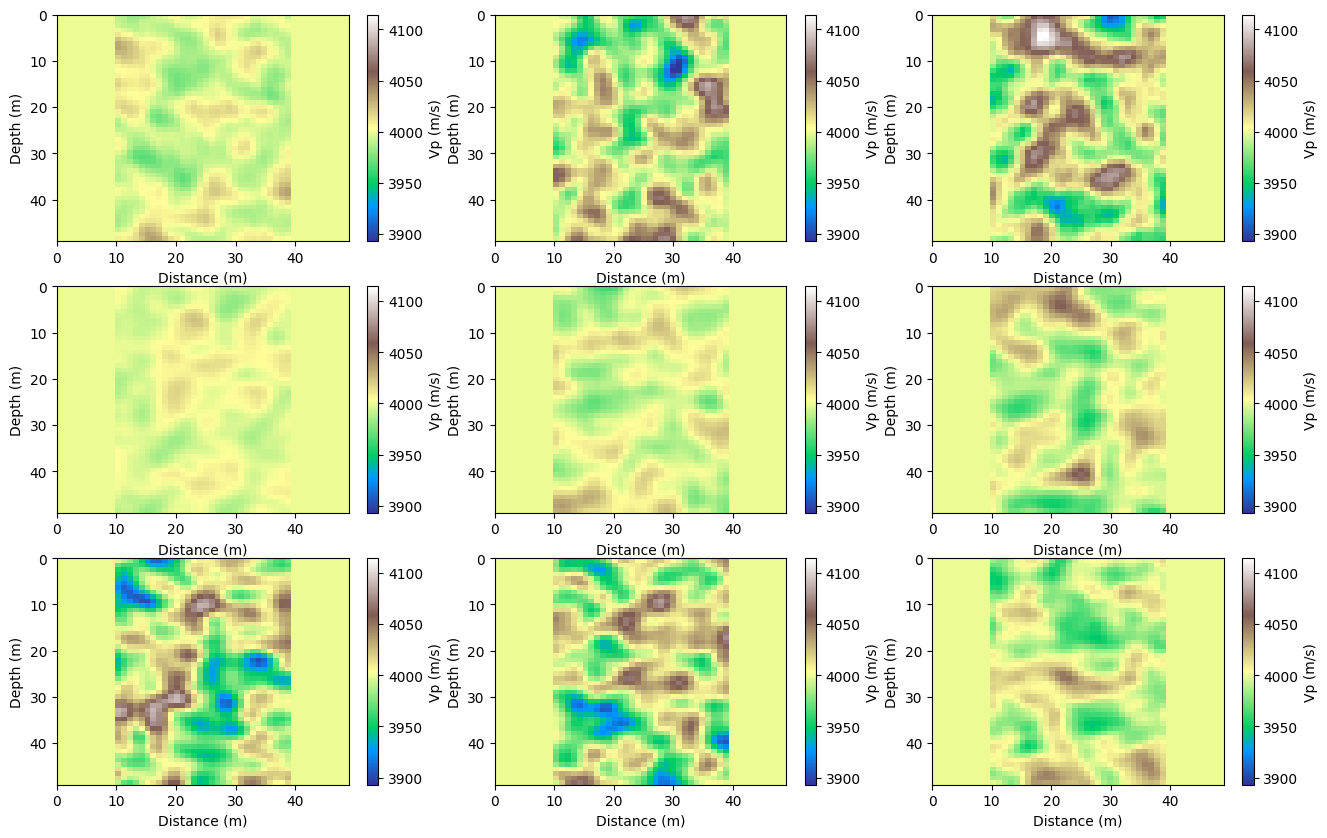

In [10]:
########Step 5 ASVGD tomography inversion based on DISC method
v_init=v_low*np.ones_like(v_true) #####initialize starting model

###create pertubations for each particles
nump=10 ##number of particles used for inversion

grf, variances = generate_random_field_perturbations(ny,nx,nump, distribution='uniform', 
                                                     min_var=10, max_var=2000, 
                                                     seed=20170590, len_scale=2, 
                                                     nu=5)
grfmin=grf.min()
grfmax=grf.max()

print(grf.min(),grf.max())


grf1=grf.reshape(grf.shape[0],ny,nx)
grf1[:,:,0:10]=0
grf1[:,:,nx-10:nx]=0
grf1=grf1.reshape(grf.shape[0],ny*nx)

address=os.getcwd()
figadd=address+'/Figure/'




#######generate initial partiles 
X_init = v_init.copy()
X_init = np.repeat(X_init.reshape(1, -1), nump, axis=0)

print(X_init.shape)
X_init = X_init + grf1

parmin=X_init.min()
parmax=X_init.max()

####display some of the initial particles
plt.figure(figsize=(16,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_init[i].reshape(ny, nx),cmap='terrain', vmin=parmin, vmax=parmax,extent=[0, (nx-1)*dx, (ny-1)*dx, 0],aspect='auto');
    plt.colorbar(label='Vp (m/s)')
    plt.xlabel('Distance (m)')
    plt.ylabel('Depth (m)')
plt.savefig(figadd+"checkpar.png", dpi=300,bbox_inches='tight')	


In [ ]:
print(grf.shape)
print(X_init.shape)

X=torch.tensor(X_init).to(device) ####slowness initial particles
X.requires_grad = True

stepray=0.5  ###step size of ray tracing
initer=8     ### initer iteration for CG
oniter=30     ### oniter iteration for ASVGD iteration
nm=nx*ny     ### number of parameters of the model

par_S={'nm':nm,'nd':nm,'nbox':[3,3,1],'ndat':[nx,ny,1],'ndim':3} ### shaping operator setting


grad_func = lambda x: compute_gradient(  ####function definition for gradient calculation
    x,
    sources,
    receivers,
    ny,
    nx,
    dy,
    dx,
    obst,
    stepray,
    par_S,
    initer,
    nd
)


(10, 2500)
(10, 2500)


  0%|          | 0/30 [00:00<?, ?it/s]/home/lcgeo/geo/xwelltomo/github/functions.py:542: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  sigma = math.sqrt(h)
 13%|█▎        | 4/30 [01:12<07:50, 18.11s/it, iter=3, loss=1.1e-5] 

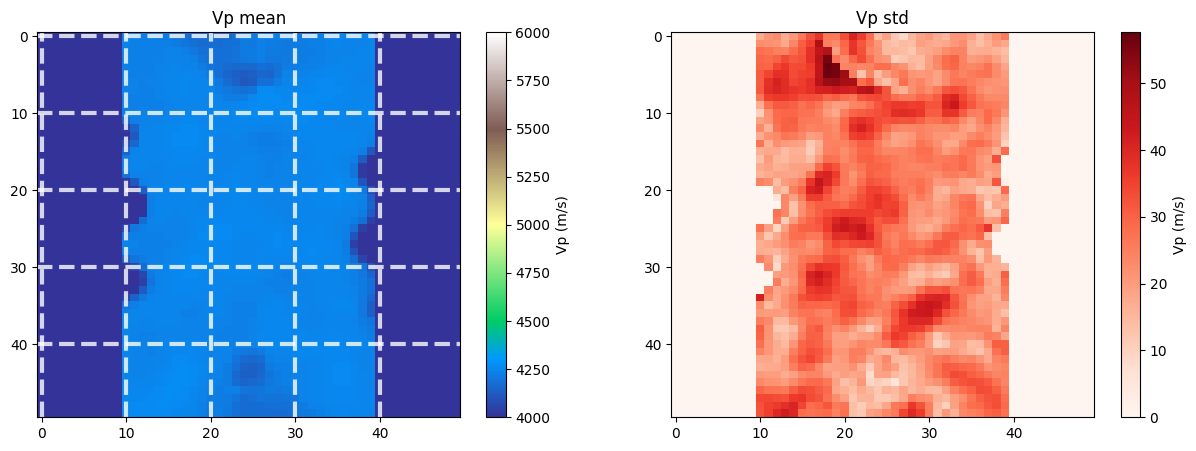

 30%|███       | 9/30 [02:43<06:20, 18.12s/it, iter=8, loss=7.89e-6]

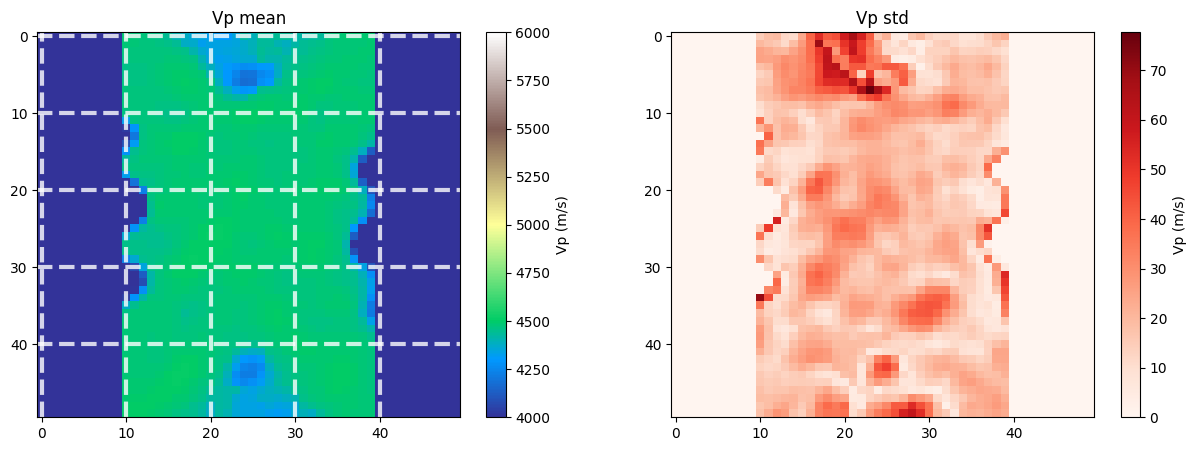

 47%|████▋     | 14/30 [04:13<04:48, 18.04s/it, iter=13, loss=5.71e-6]

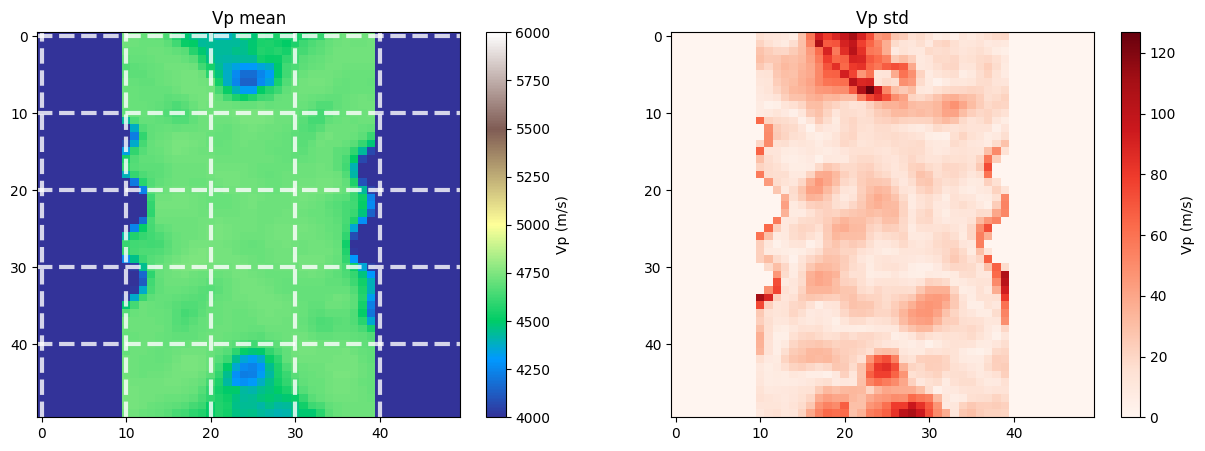

 63%|██████▎   | 19/30 [05:43<03:18, 18.08s/it, iter=18, loss=4.24e-6]

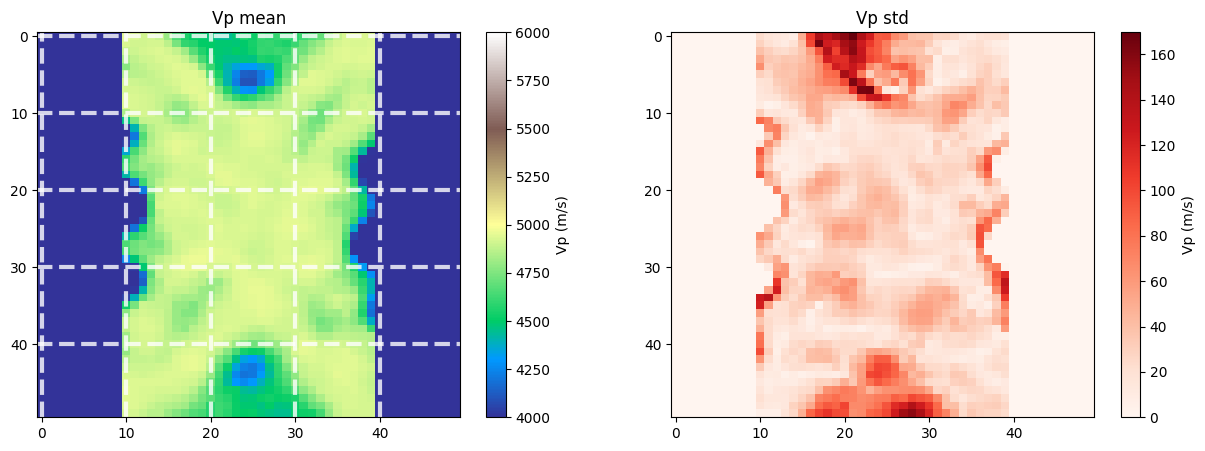

 80%|████████  | 24/30 [07:13<01:47, 17.98s/it, iter=23, loss=3.29e-6]

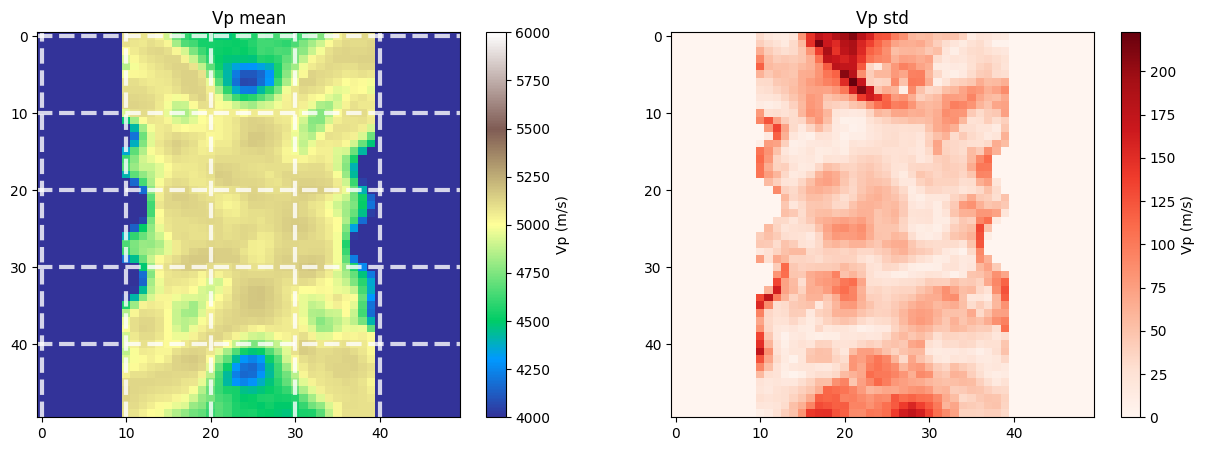

 97%|█████████▋| 29/30 [08:43<00:18, 18.03s/it, iter=28, loss=2.64e-6]

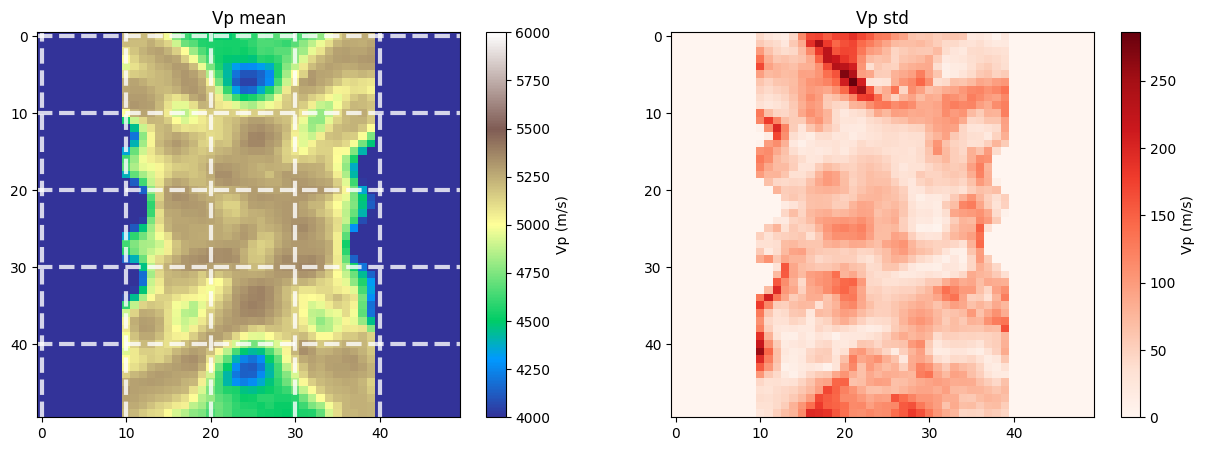

100%|██████████| 30/30 [09:01<00:00, 18.06s/it, iter=29, loss=2.54e-6]


In [7]:
########Step 5 ASVGD tomography inversion using DISC method
K = RBF()  ####define kernel function
# alpha = alpha_tanh(10, p=3)
alpha = alpha_tanh(100, p=3, device='cpu')
alpha[:]=1
optimizer = torch.optim.Adam([X],lr=50)
svgd = SVGD(X, K, alpha, optimizer,  device='cuda')

import gc
from tqdm import tqdm

epochs = tqdm(range(oniter))

for i in epochs:  
    # print(i)

    
    running_loss=0
    running_loss,grad = compute_gradient_per_batch(X_init, grad_func)
    ####grad is the gradient for slowness
    

    grad_collection = torch.zeros_like(X)
    for ig, sgrad in enumerate(grad):
        smooth_grad = sgrad.reshape(ny, nx) 
        ####the left part and the right part are not updated considering the geometry 
        smooth_grad[:,0:10]=0  
        smooth_grad[:,nx-10:nx]=0

        smooth_grad = torch.from_numpy(smooth_grad).to(device).reshape(1, -1)
        grad_collection[ig] = smooth_grad.ravel()
    
    if i == 0:
        gmax = compute_max_gradient_per_batch(grad)
        gmax = torch.tensor(gmax).to(device=device)

    svgd.step(X, grad_collection,v_low, v_hig, i, gmax, EMA=None) ###update for slowness model

    X_init=X.detach().cpu().numpy()
  
      
    if (i+1) % 5 == 0:
        gc.collect()
        torch.cuda.empty_cache()
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 2, 1)
        plt.imshow((X_init.mean(0)).astype(np.float16).reshape(ny,nx),cmap='terrain', aspect='auto',vmax=v_hig,vmin=v_low)
        plt.title('Vp mean')
        plt.colorbar(label='Vp (m/s)')
        plt.grid(True, which='both', linestyle='--', linewidth=3, alpha=0.8,color='white')
        # plt.plot(sources_x,sources_y,'r^',  markersize=15)
        # plt.plot(receivers_x,receivers_y,'y*',  markersize=15)
        plt.subplot(1, 2, 2)
        plt.imshow((X_init.std(0)).astype(np.float16).reshape(ny,nx),cmap='Reds', aspect='auto')
        plt.title('Vp std')
        plt.colorbar(label='Vp (m/s)')
        plt.show()

    # Update tqdm postfix
    epochs.set_postfix(iter=i, loss=running_loss)

	
	



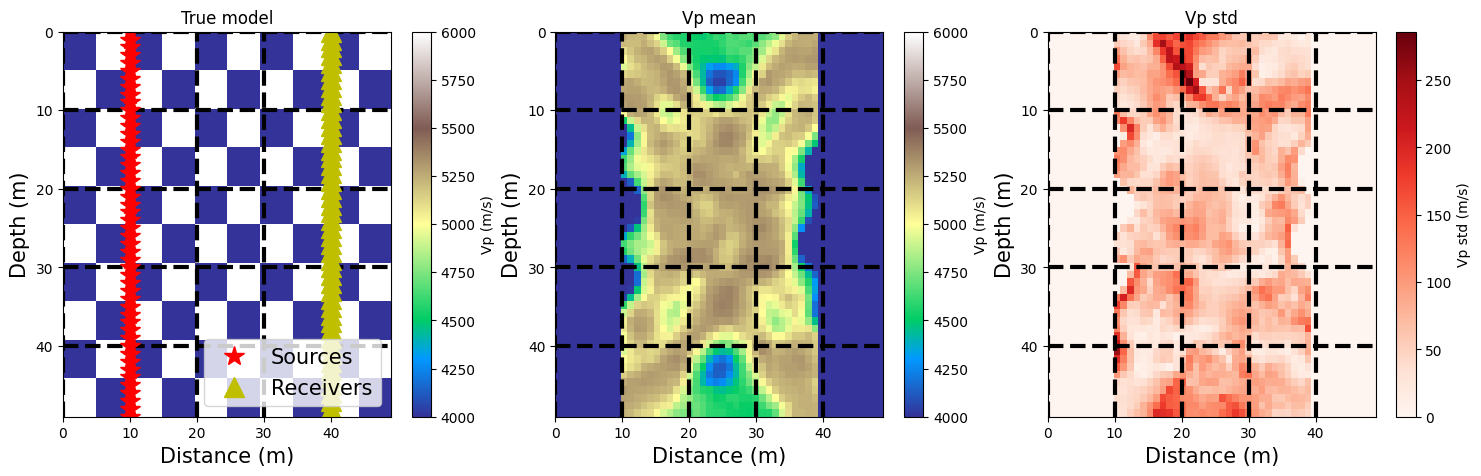

In [ ]:
#####final result display
vasp=1

plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.imshow(v_true,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect='auto')
plt.ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
plt.colorbar(label='Vp (m/s)')
plt.title('True model')
plt.plot(sources_x,sources_y,'r*',  markersize=15)
plt.plot(receivers_x,receivers_y,'y^',  markersize=15)
plt.legend(['Sources','Receivers'],loc='lower right',prop={'family': 'DejaVu Sans', 'size': 15, 'weight': 'normal'})
plt.grid(True, which='both', linestyle='--', linewidth=3, alpha=1,color='black')
plt.subplot(1,3,2)
plt.imshow((X_init.mean(0)).astype(np.float16).reshape(ny,nx),cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect='auto')
plt.ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
plt.colorbar(label='Vp (m/s)')
plt.title('Vp mean')
plt.grid(True, which='both', linestyle='--', linewidth=3, alpha=1,color='black')
plt.subplot(1,3,3)
plt.imshow((X_init.std(0)).astype(np.float16).reshape(ny,nx),cmap='Reds', aspect='auto',extent=[0,(nx-1)*dx,(ny-1)*dy,0])
plt.ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
plt.xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
plt.colorbar(label='Vp std (m/s)')
plt.title('Vp std')
plt.grid(True, which='both', linestyle='--', linewidth=3, alpha=1,color='black')
# plt.savefig(figadd+"checkasvgd.png", dpi=300,bbox_inches='tight')	
plt.show()	